<a href="https://colab.research.google.com/github/Zafar488/Portfolio/blob/main/MaternalGuard_FINAL_V4_Logic_Corrected_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MaaHifazat AI — MaternalGuard FINAL V4

## Logic-Corrected Multi-Source Industry Workflow

This notebook automatically downloads and harmonizes three public maternal-health datasets:

1. UCI Maternal Health Risk — Bangladesh
2. Tanzania Maternal Health Risks Stratification (MHRS)
3. Maternal Health and High-Risk Pregnancy — Zenodo

### Final deployable feature contract

The merged production model uses only measurements genuinely available in all three sources:

- `age`
- `systolic_bp`
- `diastolic_bp`

The pipeline derives pulse pressure, mean arterial pressure, BP ratio, age squared and age–BP interactions. Other parsed variables are saved in the harmonized dataset for future specialist models, but are not used in this merged core model. This prevents source-specific missingness from acting as a hidden dataset identifier.

### Corrections in V4

- Correct parsing of heights such as `5.3''` as 5 feet 3 inches.
- Parser unit tests before data training.
- Full-record duplicate signatures, not three-feature signatures.
- Ambiguous identical full records removed.
- Duplicate records retained but duplicate-adjusted in training and evaluation.
- Source/class balancing based on effective unique signatures.
- Custom weighted hyperparameter tuning using exactly the same metric as benchmarking.
- Out-of-fold Platt probability calibration.
- Threshold optimized on calibrated out-of-fold probabilities.
- API decisions use the same calibrated probability and threshold.
- Source/class-stratified, group-safe train/test split.
- Per-source and leave-one-source-out domain-shift reports.
- Acceptance gates, out-of-distribution warnings and emergency overrides.

> Research and hackathon prototype only. It is not a clinically validated medical device and does not replace qualified healthcare professionals.

## Step 1 — Install dependencies

In [1]:
%%capture
!pip install -U \
    "pandas>=2.0,<4.0" \
    "numpy>=1.24,<3.0" \
    "scipy>=1.10" \
    "matplotlib>=3.7" \
    "scikit-learn>=1.4,<2.0" \
    "xgboost>=2.0,<4.0" \
    "ucimlrepo>=0.0.7" \
    "openpyxl>=3.1" \
    "pyarrow>=15.0" \
    "joblib>=1.3" \
    "requests>=2.31" \
    "fastapi>=0.110" \
    "uvicorn>=0.27" \
    "pydantic>=2.6"

## Step 2 — Imports and reproducibility

In [1]:
from __future__ import annotations

import hashlib
import json
import math
import random
import re
import shutil
import sys
import warnings
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterable

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import sklearn
import xgboost

from scipy.stats import randint, loguniform, uniform
from sklearn.base import clone
from sklearn.calibration import CalibrationDisplay
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    ParameterSampler,
    StratifiedGroupKFold,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

SEED = 42
FAST_MODE = True
TUNING_ITERATIONS = 10 if FAST_MODE else 35
CV_SPLITS = 5
TARGET_HIGH_RISK_RECALL = 0.90
MODEL_VERSION = "4.0.0"
RUN_DOMAIN_STRESS_TEST = True

np.random.seed(SEED)
random.seed(SEED)

ROOT = Path("/content/maternalguard_final_v4")
RAW_DIR = ROOT / "raw"
PROCESSED_DIR = ROOT / "processed"
ARTIFACT_DIR = ROOT / "artifacts"

for directory in [RAW_DIR, PROCESSED_DIR, ARTIFACT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)
print("Project root:", ROOT)

Python: 3.12.13
pandas: 3.0.3
scikit-learn: 1.9.0
XGBoost: 3.3.0
Project root: /content/maternalguard_final_v4


## Step 3 — Public dataset registry

In [2]:
DATASET_REGISTRY = {
    "uci_bangladesh": {
        "type": "uci",
        "id": 863,
        "license": "CC BY 4.0",
    },
    "tanzania_mhrs": {
        "type": "zenodo",
        "record_id": "15309733",
        "filename": "maternal_dataset_csv.csv",
        "license": "CC BY 4.0",
    },
    "zenodo_high_risk": {
        "type": "zenodo",
        "record_id": "14537882",
        "filename": "Book2.xlsx",
        "license": "CC BY 4.0",
    },
}

print(json.dumps(DATASET_REGISTRY, indent=2))

{
  "uci_bangladesh": {
    "type": "uci",
    "id": 863,
    "license": "CC BY 4.0"
  },
  "tanzania_mhrs": {
    "type": "zenodo",
    "record_id": "15309733",
    "filename": "maternal_dataset_csv.csv",
    "license": "CC BY 4.0"
  },
  "zenodo_high_risk": {
    "type": "zenodo",
    "record_id": "14537882",
    "filename": "Book2.xlsx",
    "license": "CC BY 4.0"
  }
}


## Step 4 — Download helpers

In [3]:
def stream_download(
    url: str,
    output_path: Path,
    expected_md5: str | None = None,
) -> Path:
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if output_path.exists() and output_path.stat().st_size > 0:
        print("Already downloaded:", output_path.name)
        return output_path

    with requests.get(url, stream=True, timeout=300) as response:
        response.raise_for_status()
        with output_path.open("wb") as file:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    file.write(chunk)

    if expected_md5:
        digest = hashlib.md5(output_path.read_bytes()).hexdigest()
        if digest.lower() != expected_md5.lower():
            output_path.unlink(missing_ok=True)
            raise ValueError(
                f"Checksum mismatch for {output_path.name}: {digest}"
            )

    print("Downloaded:", output_path.name)
    return output_path


def download_zenodo_file(
    record_id: str,
    filename: str,
) -> Path:
    metadata_url = f"https://zenodo.org/api/records/{record_id}"
    response = requests.get(metadata_url, timeout=90)
    response.raise_for_status()
    metadata = response.json()

    file_record = next(
        (
            item
            for item in metadata.get("files", [])
            if item.get("key") == filename
        ),
        None,
    )

    if file_record is None:
        available = [
            item.get("key")
            for item in metadata.get("files", [])
        ]
        raise FileNotFoundError(
            f"{filename} was not found. Available files: {available}"
        )

    url = (
        file_record.get("links", {}).get("content")
        or file_record.get("links", {}).get("self")
    )

    checksum = file_record.get("checksum", "")
    expected_md5 = (
        checksum.split(":", 1)[1]
        if checksum.startswith("md5:")
        else None
    )

    return stream_download(
        url=url,
        output_path=RAW_DIR / filename,
        expected_md5=expected_md5,
    )

## Step 5 — Download and load the datasets

In [4]:
from ucimlrepo import fetch_ucirepo


def load_uci() -> pd.DataFrame:
    dataset = fetch_ucirepo(id=863)
    features = dataset.data.features.reset_index(drop=True)
    targets = dataset.data.targets.reset_index(drop=True)

    if isinstance(targets, pd.Series):
        targets = targets.to_frame(name="RiskLevel")

    frame = pd.concat([features, targets], axis=1)
    frame = frame.dropna(how="all").reset_index(drop=True)
    frame.to_csv(RAW_DIR / "uci_maternal_health.csv", index=False)
    return frame


def load_best_excel_table(path: Path) -> pd.DataFrame:
    workbook = pd.ExcelFile(path)
    candidates = []

    target_column_name = "ঝুকিপূর্ণ গর্ভ"

    for sheet_name in workbook.sheet_names:
        for header_row in range(0, 11):
            try:
                frame = pd.read_excel(
                    path,
                    sheet_name=sheet_name,
                    header=header_row,
                )
                frame = frame.dropna(axis=0, how="all")
                frame = frame.dropna(axis=1, how="all")
                frame.columns = [
                    str(column).strip()
                    for column in frame.columns
                ]

                score = len(frame)
                if target_column_name in frame.columns:
                    score += 100_000
                if "Age" in frame.columns:
                    score += 10_000
                if "Gravida" in frame.columns:
                    score += 10_000

                candidates.append(
                    (score, sheet_name, header_row, frame)
                )
            except Exception:
                continue

    if not candidates:
        raise ValueError("No valid table found inside the Excel workbook.")

    candidates.sort(key=lambda item: item[0], reverse=True)
    score, sheet_name, header_row, frame = candidates[0]

    print(
        "Selected Excel table:",
        {
            "sheet": sheet_name,
            "header_row": header_row,
            "shape": frame.shape,
        },
    )
    print("Columns:", frame.columns.tolist())
    return frame.reset_index(drop=True)


uci_raw = load_uci()

tanzania_path = download_zenodo_file(
    record_id=DATASET_REGISTRY["tanzania_mhrs"]["record_id"],
    filename=DATASET_REGISTRY["tanzania_mhrs"]["filename"],
)
tanzania_raw = pd.read_csv(tanzania_path, low_memory=False)
tanzania_raw = tanzania_raw.dropna(how="all").reset_index(drop=True)

zenodo_path = download_zenodo_file(
    record_id=DATASET_REGISTRY["zenodo_high_risk"]["record_id"],
    filename=DATASET_REGISTRY["zenodo_high_risk"]["filename"],
)
zenodo_raw = load_best_excel_table(zenodo_path)

print("UCI raw shape:", uci_raw.shape)
print("Tanzania raw shape:", tanzania_raw.shape)
print("Zenodo raw shape:", zenodo_raw.shape)

Downloaded: maternal_dataset_csv.csv
Downloaded: Book2.xlsx
Selected Excel table: {'sheet': 'Sheet1', 'header_row': 1, 'shape': (998, 18)}
Columns: ['Name', 'Age', 'Gravida', 'TiTi Tika', 'গর্ভকাল', 'ওজন', 'উচ্চতা', 'রক্ত চাপ', 'রক্তস্বল্পতা', 'জন্ডিস', 'গর্ভস্হ শিশু অবস্থান', 'গর্ভস্হ শিশু নাড়াচাড়া', 'গর্ভস্হ শিশু হৃৎস্পন্দন', 'প্রসাব পরিক্ষা এলবুমিন', 'প্রসাব পরিক্ষা সুগার', 'VDRL', 'HRsAG', 'ঝুকিপূর্ণ গর্ভ']
UCI raw shape: (1014, 7)
Tanzania raw shape: (8817, 683)
Zenodo raw shape: (998, 18)


## Step 6 — Common parsing utilities

These functions handle:

- numeric values inside mixed strings;
- yes/no values;
- ordinal values such as `1st`, `2nd`, `3rd`;
- blood pressure strings such as `100/60`;
- heights such as `5.3''`;
- first available values across ANC visits.

In [5]:
def normalize_text(value: Any) -> str:
    return re.sub(
        r"\s+",
        " ",
        str(value)
        .strip()
        .lower()
        .replace("_", " ")
        .replace("-", " "),
    )


def extract_number(value: Any) -> float:
    if pd.isna(value):
        return np.nan

    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)

    text = str(value).replace(",", ".")
    match = re.search(r"[-+]?\d*\.?\d+", text)
    return float(match.group()) if match else np.nan


def numeric_series(series: pd.Series) -> pd.Series:
    return series.map(extract_number).astype(float)


def parse_binary_value(value: Any) -> float:
    if pd.isna(value):
        return np.nan

    text = normalize_text(value)

    positive = {
        "yes", "y", "true", "1", "positive", "present",
        "abnormal", "high", "high risk",
    }
    negative = {
        "no", "n", "false", "0", "negative", "absent",
        "normal", "none", "nil", "low", "low risk",
    }

    if text in positive:
        return 1.0
    if text in negative:
        return 0.0

    number = extract_number(value)
    if number in {0.0, 1.0}:
        return number

    return np.nan


def binary_series(series: pd.Series) -> pd.Series:
    return series.map(parse_binary_value).astype(float)


def parse_ordinal_value(value: Any) -> float:
    if pd.isna(value):
        return np.nan

    text = normalize_text(value)
    word_map = {
        "first": 1,
        "second": 2,
        "third": 3,
        "fourth": 4,
        "fifth": 5,
        "sixth": 6,
        "seventh": 7,
        "eighth": 8,
        "ninth": 9,
        "tenth": 10,
    }

    if text in word_map:
        return float(word_map[text])

    return extract_number(value)


def parse_bp_value(value: Any) -> tuple[float, float]:
    if pd.isna(value):
        return np.nan, np.nan

    text = str(value).replace("\\", "/")
    numbers = re.findall(r"\d+(?:\.\d+)?", text)

    if len(numbers) < 2:
        return np.nan, np.nan

    systolic = float(numbers[0])
    diastolic = float(numbers[1])

    if not (50 <= systolic <= 260):
        systolic = np.nan
    if not (30 <= diastolic <= 180):
        diastolic = np.nan

    return systolic, diastolic


def parse_bp_series(series: pd.Series) -> tuple[pd.Series, pd.Series]:
    parsed = series.map(parse_bp_value)
    systolic = parsed.map(lambda pair: pair[0]).astype(float)
    diastolic = parsed.map(lambda pair: pair[1]).astype(float)
    return systolic, diastolic


def parse_height_cm_value(value: Any) -> float:
    """Parse centimetres, metres, and feet/inches formats safely."""
    if pd.isna(value):
        return np.nan

    if isinstance(value, (int, float, np.integer, np.floating)):
        number = float(value)
        if 120 <= number <= 220:
            return number
        if 1.2 <= number <= 2.2:
            return number * 100

    text = (
        str(value)
        .strip()
        .lower()
        .replace("’", "'")
        .replace("′", "'")
        .replace("″", '"')
        .replace("“", '"')
        .replace("”", '"')
    )

    # Dataset notation: 5.3'' means 5 feet 3 inches.
    decimal_feet = re.fullmatch(
        r"\s*(\d+)[\.,](\d{1,2})\s*['\"]{1,2}\s*",
        text,
    )
    if decimal_feet:
        feet = int(decimal_feet.group(1))
        inches = int(decimal_feet.group(2))
        if 4 <= feet <= 7 and 0 <= inches <= 11:
            return (feet * 12 + inches) * 2.54

    explicit_feet = re.fullmatch(
        r"\s*(\d+)\s*(?:ft|feet|')\s*"
        r"(\d{1,2})?\s*(?:in|inch|inches|\"|'{1,2})?\s*",
        text,
    )
    if explicit_feet:
        feet = int(explicit_feet.group(1))
        inches = int(explicit_feet.group(2) or 0)
        if 4 <= feet <= 7 and 0 <= inches <= 11:
            return (feet * 12 + inches) * 2.54

    number = extract_number(value)
    if np.isnan(number):
        return np.nan
    if 120 <= number <= 220:
        return number
    if 1.2 <= number <= 2.2:
        return number * 100
    return np.nan

def first_non_null(frame: pd.DataFrame, columns: list[str]) -> pd.Series:
    available = [
        column
        for column in columns
        if column in frame.columns
    ]

    if not available:
        return pd.Series(np.nan, index=frame.index, dtype=float)

    result = pd.Series(np.nan, index=frame.index, dtype=object)

    for column in available:
        mask = result.isna() & frame[column].notna()
        result.loc[mask] = frame.loc[mask, column]

    return result


def first_numeric(frame: pd.DataFrame, columns: list[str]) -> pd.Series:
    result = pd.Series(np.nan, index=frame.index, dtype=float)

    for column in columns:
        if column not in frame.columns:
            continue

        values = numeric_series(frame[column])
        mask = result.isna() & values.notna()
        result.loc[mask] = values.loc[mask]

    return result


def first_bp(
    frame: pd.DataFrame,
    columns: list[str],
) -> tuple[pd.Series, pd.Series]:
    systolic_result = pd.Series(
        np.nan,
        index=frame.index,
        dtype=float,
    )
    diastolic_result = pd.Series(
        np.nan,
        index=frame.index,
        dtype=float,
    )

    for column in columns:
        if column not in frame.columns:
            continue

        systolic, diastolic = parse_bp_series(frame[column])
        mask = (
            systolic_result.isna()
            & diastolic_result.isna()
            & systolic.notna()
            & diastolic.notna()
        )
        systolic_result.loc[mask] = systolic.loc[mask]
        diastolic_result.loc[mask] = diastolic.loc[mask]

    return systolic_result, diastolic_result


def ordered_visit_columns(
    frame: pd.DataFrame,
    base_name: str,
    maximum_visit: int = 8,
) -> list[str]:
    return [
        f"{base_name}_v{visit}"
        for visit in range(1, maximum_visit + 1)
        if f"{base_name}_v{visit}" in frame.columns
    ]

## Step 6B — Parser unit tests

In [6]:
height_cases = {
    "5.3''": 160.02,
    "5.2''": 157.48,
    "5' 4\"": 162.56,
    "5 ft 5 in": 165.10,
    1.60: 160.00,
    160: 160.00,
}

for value, expected in height_cases.items():
    parsed = parse_height_cm_value(value)
    assert np.isclose(parsed, expected, atol=0.02), (value, parsed, expected)

assert parse_bp_value("100/60") == (100.0, 60.0)
assert parse_bp_value("120\\80") == (120.0, 80.0)
assert parse_ordinal_value("3rd") == 3.0
assert parse_binary_value("Yes") == 1.0
assert parse_binary_value("No") == 0.0

print("All parser unit tests passed.")

All parser unit tests passed.


## Step 7 — UCI source-specific parser

In [7]:
def parse_uci_source(frame: pd.DataFrame) -> pd.DataFrame:
    output = pd.DataFrame(index=frame.index)

    output["age"] = numeric_series(frame["Age"])
    output["systolic_bp"] = numeric_series(frame["SystolicBP"])
    output["diastolic_bp"] = numeric_series(frame["DiastolicBP"])
    output["blood_sugar"] = numeric_series(frame["BS"])
    output["body_temp"] = numeric_series(frame["BodyTemp"])
    output["heart_rate"] = numeric_series(frame["HeartRate"])

    # UCI temperatures are Fahrenheit.
    output["body_temp"] = (
        output["body_temp"] - 32
    ) * 5 / 9

    for column in [
        "weight_kg", "height_cm", "bmi", "gravida",
        "gestational_age", "fetal_heart_rate", "hemoglobin",
        "anemia", "previous_complications",
        "preexisting_diabetes", "gestational_diabetes",
        "hypertension_history", "vaginal_bleeding",
        "prior_cesarean", "miscarriages", "stillbirths",
    ]:
        output[column] = np.nan

    target_map = {
        "low risk": 0,
        "mid risk": 0,
        "medium risk": 0,
        "high risk": 1,
    }

    output["target"] = (
        frame["RiskLevel"]
        .map(normalize_text)
        .map(target_map)
    )

    output["dataset_source"] = "uci_bangladesh"
    output["source_row_id"] = np.arange(len(output)).astype(str)
    return output

## Step 8 — Tanzania source-specific parser

The Tanzania table contains repeated ANC visit fields. This parser uses the **first available visit**, which is more appropriate for early screening than using visit 8 only.

In [8]:
def combine_binary_or(
    frame: pd.DataFrame,
    columns: list[str],
) -> pd.Series:
    available = [
        column
        for column in columns
        if column in frame.columns
    ]

    if not available:
        return pd.Series(np.nan, index=frame.index, dtype=float)

    converted = pd.concat(
        [binary_series(frame[column]) for column in available],
        axis=1,
    )

    has_positive = (converted == 1).any(axis=1)
    has_observation = converted.notna().any(axis=1)

    result = pd.Series(np.nan, index=frame.index, dtype=float)
    result.loc[has_observation] = 0.0
    result.loc[has_positive] = 1.0
    return result


def parse_tanzania_source(frame: pd.DataFrame) -> pd.DataFrame:
    output = pd.DataFrame(index=frame.index)

    output["age"] = numeric_series(frame["age"])
    output["gravida"] = numeric_series(frame["no_pregnancy"])
    output["gestational_age"] = numeric_series(
        frame["duration_of_pregnancy_weeks_"]
    )

    output["weight_kg"] = numeric_series(frame["weight_kg"])
    output["height_cm"] = numeric_series(frame["height_cm"])

    output["bmi"] = (
        output["weight_kg"]
        / np.square(output["height_cm"] / 100)
    )

    bp_columns = ordered_visit_columns(frame, "blood_pressure")
    output["systolic_bp"], output["diastolic_bp"] = first_bp(
        frame,
        bp_columns,
    )

    output["body_temp"] = first_numeric(
        frame,
        ordered_visit_columns(frame, "body_temperature"),
    )
    output["heart_rate"] = first_numeric(
        frame,
        ordered_visit_columns(frame, "pulse_rate"),
    )

    visit_gestational_age = first_numeric(
        frame,
        ordered_visit_columns(frame, "pregnant_week_number"),
    )
    output["gestational_age"] = output[
        "gestational_age"
    ].fillna(visit_gestational_age)

    output["hemoglobin"] = first_numeric(
        frame,
        ordered_visit_columns(
            frame,
            "hemoglobin_check_result",
        ),
    )

    output["anemia"] = np.where(
        output["hemoglobin"].notna(),
        (output["hemoglobin"] < 11).astype(float),
        np.nan,
    )

    output["blood_sugar"] = first_numeric(
        frame,
        ordered_visit_columns(
            frame,
            "blood_sugar_result",
        ),
    )

    output["fetal_heart_rate"] = first_numeric(
        frame,
        ordered_visit_columns(
            frame,
            "fetal_auscaltation",
        ),
    )

    output["preexisting_diabetes"] = binary_series(
        frame["diabetes_mellitus"]
    )
    output["gestational_diabetes"] = binary_series(
        frame["gestational_diabetes"]
    )
    output["hypertension_history"] = combine_binary_or(
        frame,
        [
            "hypertension",
            "presence_of_hypertension_in_previous_pregnancies",
        ],
    )
    output["vaginal_bleeding"] = binary_series(
        frame["vaginal_bleeding"]
    )
    output["prior_cesarean"] = binary_series(
        frame["prior_caesarean_delivery"]
    )
    output["miscarriages"] = numeric_series(
        frame["number_of_miscarriages_or_abortions"]
    )
    output["stillbirths"] = numeric_series(
        frame["number_of_prior_pregnancies_with_stillbirths"]
    )

    output["previous_complications"] = combine_binary_or(
        frame,
        [
            "problems_in_current_pregnancy",
            "bleeding_in_previous_pregnancies",
            "bleeding_in_previous_deliveries",
            "bleeding_in_previous_puerperium",
            "presence_of_hypertension_in_previous_pregnancies",
            "prior_caesarean_delivery",
            "infant_weight_of_4kg_and_above",
            "miscarriages_or_abortions",
            "twin_pregnancy",
        ],
    )

    output["target"] = (
        frame["Risk"]
        .map(normalize_text)
        .map({"low": 0, "high": 1})
    )

    output["dataset_source"] = "tanzania_mhrs"
    output["source_row_id"] = np.arange(len(output)).astype(str)
    return output

## Step 9 — Bengali Zenodo source-specific parser

In [9]:
def parse_zenodo_source(frame: pd.DataFrame) -> pd.DataFrame:
    required_columns = [
        "Age",
        "Gravida",
        "গর্ভকাল",
        "ওজন",
        "উচ্চতা",
        "রক্ত চাপ",
        "গর্ভস্হ শিশু হৃৎস্পন্দন",
        "ঝুকিপূর্ণ গর্ভ",
    ]

    missing = [
        column
        for column in required_columns
        if column not in frame.columns
    ]

    if missing:
        raise ValueError(
            f"Zenodo workbook is missing expected columns: {missing}"
        )

    output = pd.DataFrame(index=frame.index)

    output["age"] = numeric_series(frame["Age"])
    output["gravida"] = frame["Gravida"].map(parse_ordinal_value)
    output["gestational_age"] = numeric_series(frame["গর্ভকাল"])
    output["weight_kg"] = numeric_series(frame["ওজন"])
    output["height_cm"] = frame["উচ্চতা"].map(parse_height_cm_value)

    output["bmi"] = (
        output["weight_kg"]
        / np.square(output["height_cm"] / 100)
    )

    output["systolic_bp"], output["diastolic_bp"] = parse_bp_series(
        frame["রক্ত চাপ"]
    )

    output["fetal_heart_rate"] = numeric_series(
        frame["গর্ভস্হ শিশু হৃৎস্পন্দন"]
    )

    if "রক্তস্বল্পতা" in frame.columns:
        output["anemia"] = binary_series(frame["রক্তস্বল্পতা"])
    else:
        output["anemia"] = np.nan

    output["blood_sugar"] = np.nan
    output["body_temp"] = np.nan
    output["heart_rate"] = np.nan
    output["hemoglobin"] = np.nan
    output["previous_complications"] = np.nan
    output["preexisting_diabetes"] = np.nan
    output["gestational_diabetes"] = np.nan
    output["hypertension_history"] = np.nan
    output["vaginal_bleeding"] = np.nan
    output["prior_cesarean"] = np.nan
    output["miscarriages"] = np.nan
    output["stillbirths"] = np.nan

    output["target"] = (
        frame["ঝুকিপূর্ণ গর্ভ"]
        .map(normalize_text)
        .map({"no": 0, "yes": 1})
    )

    output["dataset_source"] = "zenodo_high_risk"
    output["source_row_id"] = np.arange(len(output)).astype(str)
    return output

## Step 10 — Parse and validate all three sources

In [10]:
uci = parse_uci_source(uci_raw)
tanzania = parse_tanzania_source(tanzania_raw)
zenodo = parse_zenodo_source(zenodo_raw)

HARMONIZED_SOURCES = {
    "uci_bangladesh": uci,
    "tanzania_mhrs": tanzania,
    "zenodo_high_risk": zenodo,
}

EXPECTED_MINIMUM_ROWS = {
    "uci_bangladesh": 900,
    "tanzania_mhrs": 7000,
    "zenodo_high_risk": 900,
}

for source_name, frame in HARMONIZED_SOURCES.items():
    valid_target_rows = int(frame["target"].notna().sum())

    print(
        source_name,
        {
            "total_rows": len(frame),
            "valid_target_rows": valid_target_rows,
            "target_distribution": (
                frame["target"]
                .value_counts(dropna=False)
                .to_dict()
            ),
        },
    )

    if valid_target_rows < EXPECTED_MINIMUM_ROWS[source_name]:
        raise RuntimeError(
            f"{source_name} retained only {valid_target_rows} target rows. "
            "Training has been stopped to prevent another silent small-data run."
        )

    display(frame.head(3))

uci_bangladesh {'total_rows': 1014, 'valid_target_rows': 1014, 'target_distribution': {0: 742, 1: 272}}


,age,systolic_bp,diastolic_bp,blood_sugar,body_temp,heart_rate,weight_kg,height_cm,bmi,gravida,...,preexisting_diabetes,gestational_diabetes,hypertension_history,vaginal_bleeding,prior_cesarean,miscarriages,stillbirths,target,dataset_source,source_row_id
0,25.0,130.0,80.0,15.0,36.666667,86.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,uci_bangladesh,0
1,35.0,140.0,90.0,13.0,36.666667,70.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,uci_bangladesh,1
2,29.0,90.0,70.0,8.0,37.777778,80.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,uci_bangladesh,2


tanzania_mhrs {'total_rows': 8817, 'valid_target_rows': 8817, 'target_distribution': {1: 5510, 0: 3307}}


,age,gravida,gestational_age,weight_kg,height_cm,bmi,systolic_bp,diastolic_bp,body_temp,heart_rate,...,gestational_diabetes,hypertension_history,vaginal_bleeding,prior_cesarean,miscarriages,stillbirths,previous_complications,target,dataset_source,source_row_id
0,18.0,1.0,19.0,54.0,132.0,30.991736,119.0,65.0,35.8,112.0,...,0.0,0.0,0.0,0.0,NaN,2.0,0.0,1,tanzania_mhrs,0
1,18.0,3.0,38.0,54.0,149.0,24.323229,104.0,68.0,NaN,92.0,...,0.0,0.0,0.0,0.0,NaN,2.0,0.0,1,tanzania_mhrs,1
2,24.0,1.0,20.0,53.0,142.0,26.284467,104.0,68.0,36.1,101.0,...,0.0,0.0,0.0,0.0,NaN,4.0,0.0,1,tanzania_mhrs,2


zenodo_high_risk {'total_rows': 998, 'valid_target_rows': 998, 'target_distribution': {1: 666, 0: 332}}


,age,gravida,gestational_age,weight_kg,height_cm,bmi,systolic_bp,diastolic_bp,fetal_heart_rate,anemia,...,preexisting_diabetes,gestational_diabetes,hypertension_history,vaginal_bleeding,prior_cesarean,miscarriages,stillbirths,target,dataset_source,source_row_id
0,18.0,1.0,38.0,50.0,160.02,19.526368,100.0,60.0,140.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,zenodo_high_risk,0
1,25.0,2.0,38.0,60.0,157.48,24.193597,100.0,70.0,130.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,zenodo_high_risk,1
2,20.0,1.0,30.0,55.0,152.40,23.680603,100.0,60.0,120.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,zenodo_high_risk,2


## Step 11 — Technical sanity limits

In [11]:
HARMONIZED_FEATURES = [
    "age",
    "systolic_bp",
    "diastolic_bp",
    "blood_sugar",
    "body_temp",
    "heart_rate",
    "weight_kg",
    "height_cm",
    "bmi",
    "gravida",
    "gestational_age",
    "fetal_heart_rate",
    "hemoglobin",
    "anemia",
    "previous_complications",
    "preexisting_diabetes",
    "gestational_diabetes",
    "hypertension_history",
    "vaginal_bleeding",
    "prior_cesarean",
    "miscarriages",
    "stillbirths",
]

SANITY_LIMITS = {
    "age": (10, 70),
    "systolic_bp": (50, 260),
    "diastolic_bp": (30, 180),
    "blood_sugar": (1.5, 35),
    "body_temp": (30, 44),
    "heart_rate": (30, 220),
    "weight_kg": (25, 250),
    "height_cm": (120, 220),
    "bmi": (10, 80),
    "gravida": (1, 25),
    "gestational_age": (1, 45),
    "fetal_heart_rate": (50, 240),
    "hemoglobin": (3, 25),
    "anemia": (0, 1),
    "previous_complications": (0, 1),
    "preexisting_diabetes": (0, 1),
    "gestational_diabetes": (0, 1),
    "hypertension_history": (0, 1),
    "vaginal_bleeding": (0, 1),
    "prior_cesarean": (0, 1),
    "miscarriages": (0, 20),
    "stillbirths": (0, 20),
}

outlier_rows = []

for source_name, frame in HARMONIZED_SOURCES.items():
    for feature, (lower, upper) in SANITY_LIMITS.items():
        mask = (
            frame[feature].notna()
            & ~frame[feature].between(
                lower,
                upper,
                inclusive="both",
            )
        )

        if mask.any():
            outlier_rows.append({
                "dataset_source": source_name,
                "feature": feature,
                "count": int(mask.sum()),
                "lower": lower,
                "upper": upper,
                "examples": (
                    frame.loc[mask, feature]
                    .head(5)
                    .tolist()
                ),
            })
            frame.loc[mask, feature] = np.nan

outlier_report = pd.DataFrame(outlier_rows)
display(outlier_report)

,dataset_source,feature,count,lower,upper,examples
0,uci_bangladesh,heart_rate,2,30,220,"[7.0, 7.0]"
1,tanzania_mhrs,age,1,10,70,[121.0]
2,tanzania_mhrs,body_temp,1,30,44,[89.0]
3,tanzania_mhrs,heart_rate,5,30,220,"[16.0, 16.0, 16.0, 16.0, 16.0]"
4,tanzania_mhrs,weight_kg,29,25,250,"[2.0, 3.0, 3.0, 3.0, 11080.0]"
5,tanzania_mhrs,height_cm,15,120,220,"[72.0, 40.0, 118.0, 108.0, 108.0]"
6,tanzania_mhrs,bmi,38,10,80,"[121.52777777777779, 0.7620789513793628, 1.232..."
7,tanzania_mhrs,gravida,2,1,25,"[35.0, 53.0]"
8,tanzania_mhrs,hemoglobin,20,3,25,"[137.0, 25.5, 80.0, 25.5, 90.0]"
9,tanzania_mhrs,stillbirths,1,0,20,[22.0]


## Step 12 — Merge without discarding sparse but valid sources

A row is retained when:

- its target exists;
- age exists; and
- at least one additional clinical or pregnancy feature exists.

This intentionally avoids the old rule that required three UCI-style vital signs from every source.

In [12]:
pooled = pd.concat(
    HARMONIZED_SOURCES.values(),
    ignore_index=True,
)

CORE_RAW_FEATURES = [
    "age",
    "systolic_bp",
    "diastolic_bp",
]

before_filtering = len(pooled)

pooled = pooled[
    pooled["target"].notna()
    & pooled[CORE_RAW_FEATURES].notna().all(axis=1)
].copy()

pooled["target"] = pooled["target"].astype(int)

print("Rows before filtering:", before_filtering)
print("Rows with complete common model inputs:", len(pooled))

display(
    pd.crosstab(
        pooled["dataset_source"],
        pooled["target"],
        margins=True,
    ).rename(columns={0: "not_high_risk", 1: "high_risk"})
)

if len(pooled) < 9000:
    raise RuntimeError(
        f"Only {len(pooled)} rows have common model inputs; expected 9,000+."
    )

for source_name in HARMONIZED_SOURCES:
    retained = int((pooled["dataset_source"] == source_name).sum())
    if retained < 850:
        raise RuntimeError(
            f"{source_name} retained only {retained} rows after common-input filtering."
        )

Rows before filtering: 10829
Rows with complete common model inputs: 10802


target,not_high_risk,high_risk,All
dataset_source,,,
tanzania_mhrs,3297,5493,8790
uci_bangladesh,742,272,1014
zenodo_high_risk,332,666,998
All,4371,6431,10802


## Step 13 — Height-parser quality audit

The height field is not used by the final merged core model, but it is retained correctly in the harmonized research dataset.

In [13]:
zenodo_height_audit = pd.DataFrame({
    "raw_height": zenodo_raw["উচ্চতা"],
    "parsed_height_cm": zenodo["height_cm"],
})

valid_height_rate = zenodo_height_audit[
    "parsed_height_cm"
].between(120, 220).mean()

print("Zenodo valid height rate:", round(valid_height_rate, 4))
display(zenodo_height_audit.head(20))

if valid_height_rate < 0.80:
    raise RuntimeError(
        "Zenodo height parser retained fewer than 80% valid values."
    )

Zenodo valid height rate: 1.0


,raw_height,parsed_height_cm
0,5.3'',160.02
1,5.2'',157.48
2,5.0'',152.40
3,5.4'',162.56
4,5.2'',157.48
5,5.1'',154.94
6,5.0'',152.40
7,5.4'',162.56
8,5.3'',160.02
9,5.2'',157.48


## Step 14 — Full-record signatures and duplicate audit

Signatures use all available harmonized fields. Records with identical age and BP are not considered duplicates when their other observed fields differ.

In [16]:
full_signature_text = (
    pooled[HARMONIZED_FEATURES]
    .round(5)
    .map(lambda x: str(x) if pd.notna(x) else "")
    .agg("|".join, axis=1)
)

pooled["record_signature"] = (
    pooled["dataset_source"].astype(str)
    + "::"
    + pd.util.hash_pandas_object(
        full_signature_text,
        index=False,
    ).astype(str)
)

signature_label_counts = (
    pooled.groupby("record_signature")["target"]
    .nunique()
)
ambiguous_signatures = set(
    signature_label_counts[
        signature_label_counts > 1
    ].index
)

ambiguous_rows = pooled[
    pooled["record_signature"].isin(ambiguous_signatures)
].copy()

model_data = pooled[
    ~pooled["record_signature"].isin(ambiguous_signatures)
].copy().reset_index(drop=True)

model_data["duplicate_group_size"] = (
    model_data.groupby("record_signature")["record_signature"]
    .transform("size")
    .astype(int)
)

data_quality_report = {
    "rows_before_ambiguity_removal": int(len(pooled)),
    "ambiguous_signatures_removed": int(len(ambiguous_signatures)),
    "ambiguous_rows_removed": int(len(ambiguous_rows)),
    "rows_available_for_modeling": int(len(model_data)),
    "unique_full_record_signatures": int(
        model_data["record_signature"].nunique()
    ),
    "rows_in_duplicate_groups": int(
        (model_data["duplicate_group_size"] > 1).sum()
    ),
    "source_rows": model_data["dataset_source"].value_counts().to_dict(),
    "target_rows": model_data["target"].value_counts().to_dict(),
    "raw_model_features": CORE_RAW_FEATURES,
}

print(json.dumps(data_quality_report, indent=2))

if len(model_data) < 8500:
    raise RuntimeError(
        f"Only {len(model_data)} rows remain after ambiguity removal."
    )

{
  "rows_before_ambiguity_removal": 10802,
  "ambiguous_signatures_removed": 11,
  "ambiguous_rows_removed": 73,
  "rows_available_for_modeling": 10729,
  "unique_full_record_signatures": 10187,
  "rows_in_duplicate_groups": 823,
  "source_rows": {
    "tanzania_mhrs": 8790,
    "zenodo_high_risk": 998,
    "uci_bangladesh": 941
  },
  "target_rows": {
    "1": 6392,
    "0": 4337
  },
  "raw_model_features": [
    "age",
    "systolic_bp",
    "diastolic_bp"
  ]
}


## Step 15 — Save harmonized datasets and quality reports

In [17]:
pooled.to_parquet(
    PROCESSED_DIR / "maternalguard_harmonized_full.parquet",
    index=False,
)
model_data.to_parquet(
    PROCESSED_DIR / "maternalguard_model_data.parquet",
    index=False,
)
outlier_report.to_csv(
    ARTIFACT_DIR / "outlier_report.csv",
    index=False,
)
ambiguous_rows.to_csv(
    ARTIFACT_DIR / "ambiguous_rows.csv",
    index=False,
)
zenodo_height_audit.to_csv(
    ARTIFACT_DIR / "zenodo_height_audit.csv",
    index=False,
)

with open(
    ARTIFACT_DIR / "data_quality_report.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(data_quality_report, file, indent=2)

## Step 16 — Portable core feature engineering

No missingness-count or dataset-source feature is created.

In [18]:
%%writefile maternalguard_core_features.py
from __future__ import annotations

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

CORE_RAW_FEATURES = (
    "age",
    "systolic_bp",
    "diastolic_bp",
)


class MaternalGuardCoreFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, raw_features=CORE_RAW_FEATURES):
        self.raw_features = raw_features

    def fit(self, X, y=None):
        self.feature_names_in_ = np.asarray(
            list(self.raw_features),
            dtype=object,
        )
        return self

    def transform(self, X):
        features = list(self.raw_features)

        if isinstance(X, pd.DataFrame):
            frame = X.reindex(columns=features).copy()
        else:
            frame = pd.DataFrame(X, columns=features)

        frame = frame.apply(pd.to_numeric, errors="coerce")
        epsilon = 1e-8

        frame["pulse_pressure"] = (
            frame["systolic_bp"] - frame["diastolic_bp"]
        )
        frame["mean_arterial_pressure"] = (
            frame["systolic_bp"]
            + 2.0 * frame["diastolic_bp"]
        ) / 3.0
        frame["systolic_diastolic_ratio"] = (
            frame["systolic_bp"]
            / (frame["diastolic_bp"].abs() + epsilon)
        )
        frame["age_squared"] = frame["age"] ** 2
        frame["age_systolic_interaction"] = (
            frame["age"] * frame["systolic_bp"]
        )
        frame["age_diastolic_interaction"] = (
            frame["age"] * frame["diastolic_bp"]
        )

        return frame

    def get_feature_names_out(self, input_features=None):
        return np.asarray(
            [
                "age",
                "systolic_bp",
                "diastolic_bp",
                "pulse_pressure",
                "mean_arterial_pressure",
                "systolic_diastolic_ratio",
                "age_squared",
                "age_systolic_interaction",
                "age_diastolic_interaction",
            ],
            dtype=object,
        )

Writing maternalguard_core_features.py


In [19]:
from sklearn.base import clone
from maternalguard_core_features import (
    CORE_RAW_FEATURES,
    MaternalGuardCoreFeatureEngineer,
)

transformer = MaternalGuardCoreFeatureEngineer()
clone(transformer)
preview = transformer.fit_transform(
    model_data[list(CORE_RAW_FEATURES)].head(5)
)
assert preview.shape[1] == 9
assert np.isfinite(preview.to_numpy()).all()
print("Feature-engineering clone and smoke tests passed.")
display(preview)

Feature-engineering clone and smoke tests passed.


,age,systolic_bp,diastolic_bp,pulse_pressure,mean_arterial_pressure,systolic_diastolic_ratio,age_squared,age_systolic_interaction,age_diastolic_interaction
0,25.0,130.0,80.0,50.0,96.666667,1.625000,625.0,3250.0,2000.0
1,35.0,140.0,90.0,50.0,106.666667,1.555556,1225.0,4900.0,3150.0
2,29.0,90.0,70.0,20.0,76.666667,1.285714,841.0,2610.0,2030.0
3,30.0,140.0,85.0,55.0,103.333333,1.647059,900.0,4200.0,2550.0
4,35.0,120.0,60.0,60.0,80.000000,2.000000,1225.0,4200.0,2100.0


## Step 17 — Duplicate-adjusted, source/class-balanced weights

Every full-record signature contributes total duplicate weight 1. Every source/class combination then contributes equal total analytical weight.

In [20]:
def calculate_analysis_weights(
    sources: pd.Series,
    targets: pd.Series,
    groups: pd.Series,
) -> np.ndarray:
    table = pd.DataFrame({
        "source": sources.reset_index(drop=True),
        "target": targets.reset_index(drop=True),
        "group": groups.reset_index(drop=True),
    })

    group_size = (
        table.groupby("group")["group"]
        .transform("size")
        .astype(float)
    )
    duplicate_adjustment = 1.0 / group_size

    effective_counts = (
        pd.DataFrame({
            "source": table["source"],
            "target": table["target"],
            "duplicate_adjustment": duplicate_adjustment,
        })
        .groupby(["source", "target"])["duplicate_adjustment"]
        .sum()
    )

    weights = np.asarray([
        duplicate_adjustment.iloc[index]
        / float(effective_counts.loc[(source, target)])
        for index, (source, target) in enumerate(
            zip(table["source"], table["target"])
        )
    ])

    return weights / weights.mean()


audit_weights = calculate_analysis_weights(
    model_data["dataset_source"],
    model_data["target"],
    model_data["record_signature"],
)

weight_audit = pd.DataFrame({
    "source": model_data["dataset_source"],
    "target": model_data["target"],
    "group": model_data["record_signature"],
    "weight": audit_weights,
}).groupby(["source", "target"]).agg(
    rows=("weight", "size"),
    unique_signatures=("group", "nunique"),
    total_weight=("weight", "sum"),
    mean_weight=("weight", "mean"),
)

display(weight_audit.round(4))

rows  unique_signatures  total_weight  mean_weight
source           target                                                    
tanzania_mhrs    0       3297               3293     1788.1667       0.5424
                 1       5493               5492     1788.1667       0.3255
uci_bangladesh   0        708                304     1788.1667       2.5257
                 1        233                101     1788.1667       7.6745
zenodo_high_risk 0        332                332     1788.1667       5.3860
                 1        666                665     1788.1667       2.6849

## Step 18 — Source/class-stratified group-safe holdout

In [21]:
X_all = model_data[list(CORE_RAW_FEATURES)].copy()
y_all = model_data["target"].copy()
source_all = model_data["dataset_source"].copy()
groups_all = model_data["record_signature"].copy()

composite_strata = (
    source_all.astype(str)
    + "__class_"
    + y_all.astype(str)
)

outer_splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)
train_indices, test_indices = next(
    outer_splitter.split(
        X_all,
        composite_strata,
        groups=groups_all,
    )
)

X_train = X_all.iloc[train_indices].reset_index(drop=True)
X_test = X_all.iloc[test_indices].reset_index(drop=True)
y_train = y_all.iloc[train_indices].reset_index(drop=True)
y_test = y_all.iloc[test_indices].reset_index(drop=True)
source_train = source_all.iloc[train_indices].reset_index(drop=True)
source_test = source_all.iloc[test_indices].reset_index(drop=True)
groups_train = groups_all.iloc[train_indices].reset_index(drop=True)
groups_test = groups_all.iloc[test_indices].reset_index(drop=True)

assert set(groups_train).isdisjoint(set(groups_test))

split_audit = pd.crosstab(source_train, y_train).join(
    pd.crosstab(source_test, y_test),
    lsuffix="_train",
    rsuffix="_test",
)
display(split_audit)

for source_name in source_all.unique():
    assert source_name in set(source_train)
    assert source_name in set(source_test)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

target,0_train,1_train,0_test,1_test
dataset_source,,,,
tanzania_mhrs,2638,4394,659,1099
uci_bangladesh,566,187,142,46
zenodo_high_risk,266,532,66,134


Training rows: 8583
Test rows: 2146


## Step 19 — Candidate pipelines

In [22]:
linear_preprocessor = Pipeline([
    ("features", MaternalGuardCoreFeatureEngineer()),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])

tree_preprocessor = Pipeline([
    ("features", MaternalGuardCoreFeatureEngineer()),
    ("imputer", SimpleImputer(strategy="median")),
])

CANDIDATE_MODELS = {
    "logistic_regression": Pipeline([
        ("preprocess", linear_preprocessor),
        ("model", LogisticRegression(
            C=1.0,
            max_iter=5000,
            random_state=SEED,
        )),
    ]),
    "random_forest": Pipeline([
        ("preprocess", tree_preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=3,
            random_state=SEED,
            n_jobs=1,
        )),
    ]),
    "extra_trees": Pipeline([
        ("preprocess", tree_preprocessor),
        ("model", ExtraTreesClassifier(
            n_estimators=500,
            min_samples_leaf=3,
            random_state=SEED,
            n_jobs=1,
        )),
    ]),
    "xgboost": Pipeline([
        ("preprocess", tree_preprocessor),
        ("model", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            n_estimators=450,
            max_depth=4,
            learning_rate=0.04,
            min_child_weight=3,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.01,
            reg_lambda=3.0,
            random_state=SEED,
            tree_method="hist",
            n_jobs=1,
        )),
    ]),
}

print("Candidate models:", list(CANDIDATE_MODELS))

Candidate models: ['logistic_regression', 'random_forest', 'extra_trees', 'xgboost']


## Step 20 — Weighted metrics and shared CV evaluator

In [23]:
def high_risk_recall(y_true, y_pred, sample_weight=None):
    return recall_score(
        y_true, y_pred,
        pos_label=1,
        sample_weight=sample_weight,
        zero_division=0,
    )


def high_risk_precision(y_true, y_pred, sample_weight=None):
    return precision_score(
        y_true, y_pred,
        pos_label=1,
        sample_weight=sample_weight,
        zero_division=0,
    )


def safety_score(y_true, y_pred, sample_weight=None):
    recall = high_risk_recall(y_true, y_pred, sample_weight)
    macro_f1 = f1_score(
        y_true, y_pred,
        average="macro",
        sample_weight=sample_weight,
        zero_division=0,
    )
    balanced = balanced_accuracy_score(
        y_true, y_pred,
        sample_weight=sample_weight,
    )
    return 0.55 * recall + 0.30 * macro_f1 + 0.15 * balanced


def calculate_metrics(y_true, predictions, probabilities, sample_weight=None):
    return {
        "safety": safety_score(y_true, predictions, sample_weight),
        "roc_auc": roc_auc_score(
            y_true, probabilities,
            sample_weight=sample_weight,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true, predictions,
            sample_weight=sample_weight,
        ),
        "macro_f1": f1_score(
            y_true, predictions,
            average="macro",
            sample_weight=sample_weight,
            zero_division=0,
        ),
        "high_risk_recall": high_risk_recall(
            y_true, predictions, sample_weight,
        ),
        "high_risk_precision": high_risk_precision(
            y_true, predictions, sample_weight,
        ),
        "log_loss": log_loss(
            y_true, probabilities,
            sample_weight=sample_weight,
            labels=[0, 1],
        ),
    }


def fit_pipeline(estimator, X, y, sample_weight):
    model = clone(estimator)
    model.fit(X, y, model__sample_weight=sample_weight)
    return model


def evaluate_estimator_cv(estimator, X, y, sources, groups, splits):
    rows = []

    for fold_number, (fit_idx, valid_idx) in enumerate(splits, start=1):
        fit_weights = calculate_analysis_weights(
            sources.iloc[fit_idx], y.iloc[fit_idx], groups.iloc[fit_idx]
        )
        valid_weights = calculate_analysis_weights(
            sources.iloc[valid_idx], y.iloc[valid_idx], groups.iloc[valid_idx]
        )

        model = fit_pipeline(
            estimator,
            X.iloc[fit_idx],
            y.iloc[fit_idx],
            fit_weights,
        )
        probabilities = model.predict_proba(X.iloc[valid_idx])[:, 1]
        predictions = (probabilities >= 0.5).astype(int)
        metrics = calculate_metrics(
            y.iloc[valid_idx], predictions, probabilities, valid_weights
        )
        metrics["fold"] = fold_number
        rows.append(metrics)

    return pd.DataFrame(rows)

## Step 21 — Cross-validation folds and baseline benchmark

In [24]:
train_composite = (
    source_train.astype(str)
    + "__class_"
    + y_train.astype(str)
)
inner_splitter = StratifiedGroupKFold(
    n_splits=CV_SPLITS,
    shuffle=True,
    random_state=SEED,
)
CV_SPLITS_LIST = list(
    inner_splitter.split(
        X_train,
        train_composite,
        groups=groups_train,
    )
)

benchmark_rows = []
for model_name, estimator in CANDIDATE_MODELS.items():
    print("Evaluating:", model_name)
    report = evaluate_estimator_cv(
        estimator,
        X_train,
        y_train,
        source_train,
        groups_train,
        CV_SPLITS_LIST,
    )
    report.to_csv(
        ARTIFACT_DIR / f"baseline_folds_{model_name}.csv",
        index=False,
    )
    benchmark_rows.append({
        "model": model_name,
        "mean_safety": report["safety"].mean(),
        "std_safety": report["safety"].std(),
        "mean_roc_auc": report["roc_auc"].mean(),
        "mean_balanced_accuracy": report["balanced_accuracy"].mean(),
        "mean_macro_f1": report["macro_f1"].mean(),
        "mean_high_risk_recall": report["high_risk_recall"].mean(),
        "mean_high_risk_precision": report["high_risk_precision"].mean(),
    })

benchmark = pd.DataFrame(benchmark_rows).sort_values(
    ["mean_safety", "mean_roc_auc"],
    ascending=False,
).reset_index(drop=True)

display(benchmark.round(4))
benchmark.to_csv(ARTIFACT_DIR / "baseline_benchmark.csv", index=False)

Evaluating: logistic_regression
Evaluating: random_forest
Evaluating: extra_trees
Evaluating: xgboost


,model,mean_safety,std_safety,mean_roc_auc,mean_balanced_accuracy,mean_macro_f1,mean_high_risk_recall,mean_high_risk_precision
0,extra_trees,0.6855,0.0336,0.7623,0.6820,0.6819,0.6885,0.6793
1,random_forest,0.6851,0.0323,0.7634,0.6864,0.6862,0.6842,0.6870
2,xgboost,0.6775,0.0277,0.7647,0.6876,0.6875,0.6693,0.6945
3,logistic_regression,0.4967,0.0230,0.5959,0.5640,0.5574,0.4453,0.5848


## Step 22 — Custom weighted hyperparameter tuning

Benchmarking and tuning use the same custom fold weights and safety metric.

In [25]:
best_family = benchmark.iloc[0]["model"]
base_estimator = CANDIDATE_MODELS[best_family]

PARAMETER_SPACES = {
    "logistic_regression": {
        "model__C": loguniform(1e-3, 1e2),
    },
    "random_forest": {
        "model__n_estimators": randint(300, 901),
        "model__max_depth": [None, 5, 8, 12, 16, 24],
        "model__min_samples_split": randint(2, 20),
        "model__min_samples_leaf": randint(1, 10),
        "model__max_features": ["sqrt", "log2", 0.6, 0.8, None],
    },
    "extra_trees": {
        "model__n_estimators": randint(300, 901),
        "model__max_depth": [None, 5, 8, 12, 16, 24],
        "model__min_samples_split": randint(2, 20),
        "model__min_samples_leaf": randint(1, 10),
        "model__max_features": ["sqrt", "log2", 0.6, 0.8, None],
    },
    "xgboost": {
        "model__n_estimators": randint(250, 801),
        "model__max_depth": randint(2, 9),
        "model__learning_rate": loguniform(0.01, 0.20),
        "model__min_child_weight": randint(1, 12),
        "model__subsample": uniform(0.65, 0.35),
        "model__colsample_bytree": uniform(0.65, 0.35),
        "model__reg_alpha": loguniform(1e-5, 2.0),
        "model__reg_lambda": loguniform(0.1, 15.0),
    },
}

# The default baseline is included so tuning cannot silently select
# a model worse than the baseline merely due to random sampling.
parameter_candidates = [{}] + list(
    ParameterSampler(
        PARAMETER_SPACES[best_family],
        n_iter=TUNING_ITERATIONS,
        random_state=SEED,
    )
)

tuning_rows = []
for candidate_number, parameters in enumerate(parameter_candidates, start=1):
    print(f"Candidate {candidate_number}/{len(parameter_candidates)}")
    estimator = clone(base_estimator).set_params(**parameters)
    report = evaluate_estimator_cv(
        estimator,
        X_train,
        y_train,
        source_train,
        groups_train,
        CV_SPLITS_LIST,
    )
    tuning_rows.append({
        "candidate": candidate_number,
        "parameters": parameters,
        "mean_safety": report["safety"].mean(),
        "std_safety": report["safety"].std(),
        "mean_roc_auc": report["roc_auc"].mean(),
        "mean_balanced_accuracy": report["balanced_accuracy"].mean(),
        "mean_macro_f1": report["macro_f1"].mean(),
        "mean_high_risk_recall": report["high_risk_recall"].mean(),
        "mean_high_risk_precision": report["high_risk_precision"].mean(),
    })

tuning_results = pd.DataFrame(tuning_rows).sort_values(
    ["mean_safety", "mean_roc_auc", "std_safety"],
    ascending=[False, False, True],
).reset_index(drop=True)

best_parameters = tuning_results.iloc[0]["parameters"]
best_estimator = clone(base_estimator).set_params(**best_parameters)

print("Best family:", best_family)
print("Best parameters:", json.dumps(best_parameters, indent=2, default=str))
display(tuning_results.head(10))

export = tuning_results.copy()
export["parameters"] = export["parameters"].map(
    lambda value: json.dumps(value, default=str)
)
export.to_csv(ARTIFACT_DIR / "weighted_tuning_results.csv", index=False)

Candidate 1/11
Candidate 2/11
Candidate 3/11
Candidate 4/11
Candidate 5/11
Candidate 6/11
Candidate 7/11
Candidate 8/11
Candidate 9/11
Candidate 10/11
Candidate 11/11
Best family: extra_trees
Best parameters: {}


,candidate,parameters,mean_safety,std_safety,mean_roc_auc,mean_balanced_accuracy,mean_macro_f1,mean_high_risk_recall,mean_high_risk_precision
0,1,{},0.685542,0.033587,0.762260,0.681981,0.681916,0.688491,0.679315
1,5,"{'model__max_depth': 24, 'model__max_features'...",0.685339,0.032839,0.768276,0.683066,0.682963,0.687256,0.681267
2,4,"{'model__max_depth': 24, 'model__max_features'...",0.682402,0.034853,0.760097,0.683537,0.683453,0.681520,0.683768
3,2,"{'model__max_depth': 12, 'model__max_features'...",0.682099,0.033689,0.773622,0.687781,0.687586,0.677558,0.691526
4,11,"{'model__max_depth': 12, 'model__max_features'...",0.681742,0.034979,0.774808,0.687626,0.687443,0.677027,0.691410
5,9,"{'model__max_depth': None, 'model__max_feature...",0.681101,0.037283,0.766227,0.680976,0.680924,0.681232,0.680385
6,8,"{'model__max_depth': 12, 'model__max_features'...",0.677424,0.033995,0.763737,0.686022,0.685797,0.670513,0.691701
7,3,"{'model__max_depth': 8, 'model__max_features':...",0.648213,0.045934,0.755185,0.673814,0.672769,0.627836,0.690940
8,6,"{'model__max_depth': 5, 'model__max_features':...",0.647461,0.032726,0.737154,0.667006,0.666239,0.631887,0.679987
9,7,"{'model__max_depth': 8, 'model__max_features':...",0.635595,0.036275,0.748072,0.670652,0.669074,0.607773,0.695156


## Step 23 — OOF probabilities, Platt calibration and calibrated threshold

In [26]:
def generate_oof_probabilities(estimator, X, y, sources, groups, splits):
    probabilities = np.full(len(X), np.nan, dtype=float)

    for fit_idx, valid_idx in splits:
        weights = calculate_analysis_weights(
            sources.iloc[fit_idx], y.iloc[fit_idx], groups.iloc[fit_idx]
        )
        model = fit_pipeline(
            estimator,
            X.iloc[fit_idx],
            y.iloc[fit_idx],
            weights,
        )
        probabilities[valid_idx] = model.predict_proba(
            X.iloc[valid_idx]
        )[:, 1]

    if np.isnan(probabilities).any():
        raise RuntimeError("OOF probability generation is incomplete.")
    return probabilities


def probability_to_logit(probabilities):
    clipped = np.clip(np.asarray(probabilities, dtype=float), 1e-6, 1 - 1e-6)
    return np.log(clipped / (1 - clipped)).reshape(-1, 1)


def fit_platt_calibrator(raw_probabilities, targets, sample_weight):
    calibrator = LogisticRegression(
        C=1e6,
        solver="lbfgs",
        max_iter=3000,
        random_state=SEED,
    )
    calibrator.fit(
        probability_to_logit(raw_probabilities),
        targets,
        sample_weight=sample_weight,
    )
    return calibrator


def apply_calibrator(calibrator, raw_probabilities):
    return calibrator.predict_proba(
        probability_to_logit(raw_probabilities)
    )[:, 1]


def select_threshold(probabilities, targets, weights):
    rows = []
    for threshold in np.round(np.arange(0.05, 0.96, 0.01), 2):
        predictions = (probabilities >= threshold).astype(int)
        metrics = calculate_metrics(
            targets, predictions, probabilities, weights
        )
        rows.append({
            "threshold": float(threshold),
            "safety": metrics["safety"],
            "recall": metrics["high_risk_recall"],
            "precision": metrics["high_risk_precision"],
            "macro_f1": metrics["macro_f1"],
            "balanced_accuracy": metrics["balanced_accuracy"],
        })

    table = pd.DataFrame(rows)
    eligible = table[table["recall"] >= TARGET_HIGH_RISK_RECALL]
    if not eligible.empty:
        selected = eligible.sort_values(
            ["macro_f1", "precision", "balanced_accuracy", "threshold"],
            ascending=[False, False, False, False],
        ).iloc[0]
    else:
        selected = table.sort_values(
            ["recall", "macro_f1", "precision"],
            ascending=False,
        ).iloc[0]
    return float(selected["threshold"]), table, selected


oof_raw = generate_oof_probabilities(
    best_estimator,
    X_train,
    y_train,
    source_train,
    groups_train,
    CV_SPLITS_LIST,
)
oof_weights = calculate_analysis_weights(
    source_train,
    y_train,
    groups_train,
)
platt_calibrator = fit_platt_calibrator(oof_raw, y_train, oof_weights)
oof_calibrated = apply_calibrator(platt_calibrator, oof_raw)

HIGH_RISK_THRESHOLD, threshold_table, selected_threshold = select_threshold(
    oof_calibrated,
    y_train,
    oof_weights,
)

print("Selected calibrated threshold:", HIGH_RISK_THRESHOLD)
display(selected_threshold.to_frame("value"))
threshold_table.to_csv(
    ARTIFACT_DIR / "calibrated_threshold_analysis.csv",
    index=False,
)

Selected calibrated threshold: 0.32


,value
threshold,0.320000
safety,0.777112
recall,0.912062
precision,0.585258
macro_f1,0.601828
balanced_accuracy,0.632866


## Step 24 — Fit the training model and evaluate the untouched test set

In [27]:
training_weights = calculate_analysis_weights(
    source_train,
    y_train,
    groups_train,
)
decision_model = fit_pipeline(
    best_estimator,
    X_train,
    y_train,
    training_weights,
)

raw_test_probabilities = decision_model.predict_proba(X_test)[:, 1]
calibrated_test_probabilities = apply_calibrator(
    platt_calibrator,
    raw_test_probabilities,
)
test_predictions = (
    calibrated_test_probabilities >= HIGH_RISK_THRESHOLD
).astype(int)

test_weights = calculate_analysis_weights(
    source_test,
    y_test,
    groups_test,
)

unweighted_test_metrics = calculate_metrics(
    y_test,
    test_predictions,
    calibrated_test_probabilities,
    None,
)
source_balanced_test_metrics = calculate_metrics(
    y_test,
    test_predictions,
    calibrated_test_probabilities,
    test_weights,
)

print("Unweighted metrics:")
print(json.dumps(unweighted_test_metrics, indent=2))
print("\nSource/class/duplicate-balanced metrics:")
print(json.dumps(source_balanced_test_metrics, indent=2))
print("\nClassification report:")
print(classification_report(
    y_test,
    test_predictions,
    target_names=["not_high_risk", "high_risk"],
    zero_division=0,
))

Unweighted metrics:
{
  "safety": 0.7777694870173321,
  "roc_auc": 0.6519064508478276,
  "balanced_accuracy": 0.5881996730072243,
  "macro_f1": 0.5583035356495485,
  "high_risk_recall": 0.9491790461297889,
  "high_risk_precision": 0.6443736730360934,
  "log_loss": 0.6440309313859897
}

Source/class/duplicate-balanced metrics:
{
  "safety": 0.8115771540886414,
  "roc_auc": 0.7987945368404424,
  "balanced_accuracy": 0.6559811324442926,
  "macro_f1": 0.6215340922722484,
  "high_risk_recall": 0.9576722846187689,
  "high_risk_precision": 0.5972825582652538,
  "log_loss": 0.5326146816239974
}

Classification report:
               precision    recall  f1-score   support

not_high_risk       0.75      0.23      0.35       867
    high_risk       0.64      0.95      0.77      1279

     accuracy                           0.66      2146
    macro avg       0.70      0.59      0.56      2146
 weighted avg       0.69      0.66      0.60      2146



<Figure size 700x600 with 0 Axes>

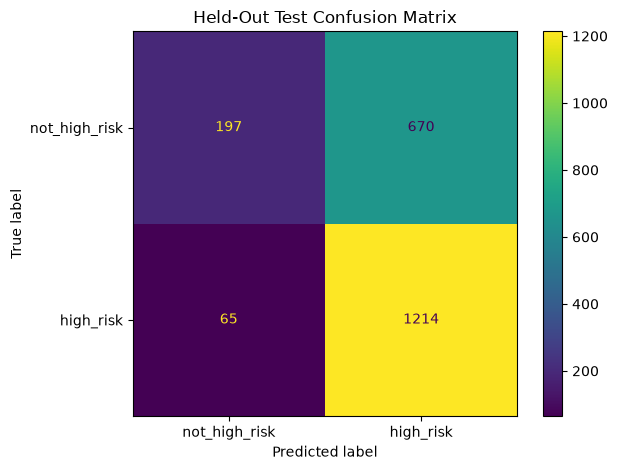

In [28]:
plt.figure(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=["not_high_risk", "high_risk"],
    values_format="d",
)
plt.title("Held-Out Test Confusion Matrix")
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

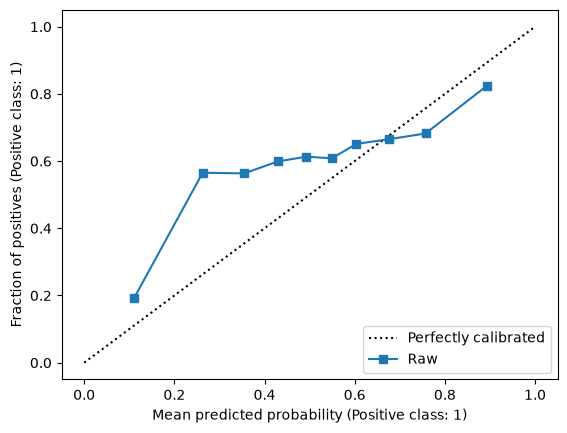

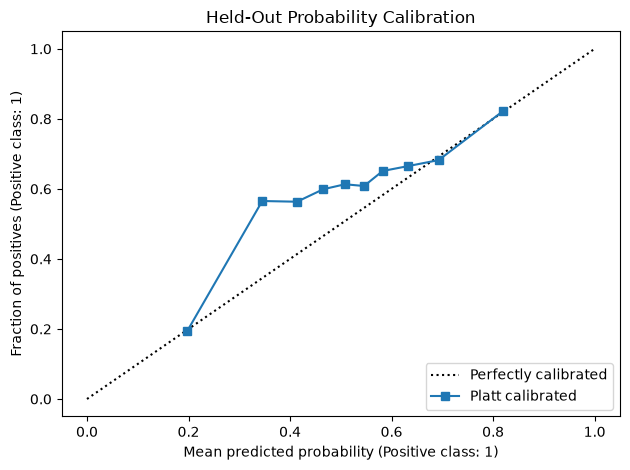

In [29]:
plt.figure(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    y_test,
    raw_test_probabilities,
    n_bins=10,
    strategy="quantile",
    name="Raw",
)
CalibrationDisplay.from_predictions(
    y_test,
    calibrated_test_probabilities,
    n_bins=10,
    strategy="quantile",
    name="Platt calibrated",
)
plt.title("Held-Out Probability Calibration")
plt.tight_layout()
plt.show()

## Step 25 — Per-source held-out metrics

In [30]:
per_source_rows = []
for source_name in sorted(source_test.unique()):
    mask = source_test == source_name
    source_y = y_test.loc[mask]
    source_predictions = test_predictions[mask.to_numpy()]
    source_probabilities = calibrated_test_probabilities[mask.to_numpy()]
    source_weights = calculate_analysis_weights(
        source_test.loc[mask],
        source_y,
        groups_test.loc[mask],
    )
    metrics = calculate_metrics(
        source_y,
        source_predictions,
        source_probabilities,
        source_weights,
    )
    metrics.update({
        "dataset_source": source_name,
        "rows": int(mask.sum()),
    })
    per_source_rows.append(metrics)

per_source_metrics = pd.DataFrame(per_source_rows)
display(per_source_metrics.round(4))
per_source_metrics.to_csv(
    ARTIFACT_DIR / "per_source_test_metrics.csv",
    index=False,
)

,safety,roc_auc,balanced_accuracy,macro_f1,high_risk_recall,high_risk_precision,log_loss,dataset_source,rows
0,0.7294,0.5718,0.5305,0.4328,0.9454,0.5166,0.7026,tanzania_mhrs,1758
1,0.8725,0.8895,0.7820,0.7757,0.9500,0.7111,0.4157,uci_bangladesh,188
2,0.8207,0.8579,0.6555,0.6156,0.9776,0.5946,0.4795,zenodo_high_risk,200


## Step 26 — Leave-one-source-out domain-shift stress test

Calibration and threshold selection are repeated using only the remaining sources; the held-out source is never used for those choices.

In [31]:
def build_cv_splits(X, y, sources, groups):
    composite = sources.astype(str) + "__class_" + y.astype(str)
    splitter = StratifiedGroupKFold(
        n_splits=CV_SPLITS,
        shuffle=True,
        random_state=SEED,
    )
    return list(splitter.split(X, composite, groups=groups))


lodo_rows = []
if RUN_DOMAIN_STRESS_TEST:
    for held_out_source in sorted(source_all.unique()):
        fit_mask = source_all != held_out_source
        holdout_mask = source_all == held_out_source

        X_fit = X_all.loc[fit_mask].reset_index(drop=True)
        y_fit = y_all.loc[fit_mask].reset_index(drop=True)
        source_fit = source_all.loc[fit_mask].reset_index(drop=True)
        group_fit = groups_all.loc[fit_mask].reset_index(drop=True)

        X_holdout = X_all.loc[holdout_mask].reset_index(drop=True)
        y_holdout = y_all.loc[holdout_mask].reset_index(drop=True)
        source_holdout = source_all.loc[holdout_mask].reset_index(drop=True)
        group_holdout = groups_all.loc[holdout_mask].reset_index(drop=True)

        splits = build_cv_splits(X_fit, y_fit, source_fit, group_fit)
        raw_oof = generate_oof_probabilities(
            best_estimator,
            X_fit,
            y_fit,
            source_fit,
            group_fit,
            splits,
        )
        fit_weights = calculate_analysis_weights(
            source_fit, y_fit, group_fit
        )
        calibrator = fit_platt_calibrator(raw_oof, y_fit, fit_weights)
        calibrated_oof = apply_calibrator(calibrator, raw_oof)
        threshold, _, _ = select_threshold(
            calibrated_oof, y_fit, fit_weights
        )

        model = fit_pipeline(
            best_estimator,
            X_fit,
            y_fit,
            fit_weights,
        )
        raw = model.predict_proba(X_holdout)[:, 1]
        probabilities = apply_calibrator(calibrator, raw)
        predictions = (probabilities >= threshold).astype(int)
        holdout_weights = calculate_analysis_weights(
            source_holdout, y_holdout, group_holdout
        )
        metrics = calculate_metrics(
            y_holdout,
            predictions,
            probabilities,
            holdout_weights,
        )
        metrics.update({
            "held_out_source": held_out_source,
            "rows": int(len(y_holdout)),
            "threshold": threshold,
        })
        lodo_rows.append(metrics)

lodo_results = pd.DataFrame(lodo_rows)
display(lodo_results.round(4))
lodo_results.to_csv(
    ARTIFACT_DIR / "leave_one_source_out_stress_test.csv",
    index=False,
)

,safety,roc_auc,balanced_accuracy,macro_f1,high_risk_recall,high_risk_precision,log_loss,held_out_source,rows,threshold
0,0.6878,0.4848,0.4977,0.4038,0.8946,0.4987,0.7713,tanzania_mhrs,8790,0.31
1,0.7119,0.5706,0.5130,0.4102,0.9307,0.5071,0.7478,uci_bangladesh,941,0.34
2,0.6408,0.4841,0.4542,0.3539,0.8481,0.4744,0.7491,zenodo_high_risk,998,0.34


## Step 27 — Source-aware permutation importance

In [32]:
def source_aware_permutation_importance(
    model,
    calibrator,
    X,
    y,
    sources,
    weights,
    repeats=15,
):
    baseline = apply_calibrator(
        calibrator,
        model.predict_proba(X)[:, 1],
    )
    baseline_auc = roc_auc_score(
        y,
        baseline,
        sample_weight=weights,
    )
    generator = np.random.default_rng(SEED)
    rows = []

    for feature in X.columns:
        decreases = []
        for _ in range(repeats):
            permuted = X.copy()
            for source_name in sources.unique():
                indices = np.where(sources.to_numpy() == source_name)[0]
                values = permuted.iloc[indices][feature].to_numpy().copy()
                generator.shuffle(values)
                permuted.iloc[
                    indices,
                    permuted.columns.get_loc(feature),
                ] = values

            probabilities = apply_calibrator(
                calibrator,
                model.predict_proba(permuted)[:, 1],
            )
            auc = roc_auc_score(
                y,
                probabilities,
                sample_weight=weights,
            )
            decreases.append(baseline_auc - auc)

        rows.append({
            "feature": feature,
            "importance_mean": float(np.mean(decreases)),
            "importance_std": float(np.std(decreases)),
        })

    return pd.DataFrame(rows).sort_values(
        "importance_mean",
        ascending=False,
    ).reset_index(drop=True)


importance_df = source_aware_permutation_importance(
    decision_model,
    platt_calibrator,
    X_test,
    y_test,
    source_test,
    test_weights,
    repeats=12 if FAST_MODE else 35,
)
display(importance_df.round(4))
importance_df.to_csv(
    ARTIFACT_DIR / "source_aware_permutation_importance.csv",
    index=False,
)

,feature,importance_mean,importance_std
0,systolic_bp,0.1791,0.0270
1,diastolic_bp,0.1742,0.0182
2,age,0.0554,0.0150


## Step 28 — Error analysis and acceptance gates

In [33]:
error_analysis = X_test.copy()
error_analysis["dataset_source"] = source_test
error_analysis["true_class"] = y_test.map({0: "not_high_risk", 1: "high_risk"})
error_analysis["predicted_class"] = pd.Series(test_predictions).map(
    {0: "not_high_risk", 1: "high_risk"}
)
error_analysis["raw_probability"] = raw_test_probabilities
error_analysis["calibrated_probability"] = calibrated_test_probabilities
error_analysis["critical_false_negative"] = (
    (y_test.to_numpy() == 1) & (test_predictions == 0)
)
error_analysis["false_positive"] = (
    (y_test.to_numpy() == 0) & (test_predictions == 1)
)
error_analysis = error_analysis.sort_values(
    ["critical_false_negative", "false_positive", "calibrated_probability"],
    ascending=[False, False, True],
)
error_analysis.to_csv(
    ARTIFACT_DIR / "heldout_error_analysis.csv",
    index=False,
)

minimum_source_balanced_accuracy = float(
    per_source_metrics["balanced_accuracy"].min()
)
acceptance_checks = {
    "model_rows_at_least_8500": len(model_data) >= 8500,
    "source_balanced_recall_at_least_0_85": (
        source_balanced_test_metrics["high_risk_recall"] >= 0.85
    ),
    "source_balanced_precision_at_least_0_55": (
        source_balanced_test_metrics["high_risk_precision"] >= 0.55
    ),
    "source_balanced_auc_at_least_0_70": (
        source_balanced_test_metrics["roc_auc"] >= 0.70
    ),
    "minimum_per_source_balanced_accuracy_at_least_0_55": (
        minimum_source_balanced_accuracy >= 0.55
    ),
}
if not lodo_results.empty:
    acceptance_checks["mean_lodo_auc_at_least_0_55"] = (
        float(lodo_results["roc_auc"].mean()) >= 0.55
    )

DEPLOYMENT_STATUS = (
    "research_candidate_passed_internal_gates"
    if all(acceptance_checks.values())
    else "research_only_failed_one_or_more_gates"
)

print("Critical false negatives:", int(error_analysis["critical_false_negative"].sum()))
print("False positives:", int(error_analysis["false_positive"].sum()))
print("Deployment status:", DEPLOYMENT_STATUS)
print(json.dumps(acceptance_checks, indent=2))
display(error_analysis.head(40))

Critical false negatives: 65
False positives: 670
Deployment status: research_only_failed_one_or_more_gates
{
  "model_rows_at_least_8500": true,
  "source_balanced_recall_at_least_0_85": true,
  "source_balanced_precision_at_least_0_55": true,
  "source_balanced_auc_at_least_0_70": true,
  "minimum_per_source_balanced_accuracy_at_least_0_55": false,
  "mean_lodo_auc_at_least_0_55": false
}


,age,systolic_bp,diastolic_bp,dataset_source,true_class,predicted_class,raw_probability,calibrated_probability,critical_false_negative,false_positive
415,21.0,120.0,80.0,tanzania_mhrs,high_risk,not_high_risk,0.034057,0.101155,True,False
542,21.0,120.0,80.0,tanzania_mhrs,high_risk,not_high_risk,0.034057,0.101155,True,False
22,30.0,120.0,80.0,uci_bangladesh,high_risk,not_high_risk,0.035395,0.103608,True,False
90,30.0,120.0,80.0,uci_bangladesh,high_risk,not_high_risk,0.035395,0.103608,True,False
1155,30.0,120.0,80.0,tanzania_mhrs,high_risk,not_high_risk,0.035395,0.103608,True,False
459,32.0,120.0,80.0,tanzania_mhrs,high_risk,not_high_risk,0.047630,0.124467,True,False
1186,32.0,120.0,80.0,tanzania_mhrs,high_risk,not_high_risk,0.047630,0.124467,True,False
256,18.0,118.0,79.0,tanzania_mhrs,high_risk,not_high_risk,0.060314,0.143808,True,False
1192,27.0,100.0,70.0,tanzania_mhrs,high_risk,not_high_risk,0.070173,0.157656,True,False
1391,28.0,115.0,60.0,tanzania_mhrs,high_risk,not_high_risk,0.087539,0.180144,True,False


## Step 29 — Full-data OOF calibration and final refit

In [34]:
full_splits = build_cv_splits(X_all, y_all, source_all, groups_all)
full_oof_raw = generate_oof_probabilities(
    best_estimator,
    X_all,
    y_all,
    source_all,
    groups_all,
    full_splits,
)
full_weights = calculate_analysis_weights(
    source_all,
    y_all,
    groups_all,
)
final_calibrator = fit_platt_calibrator(
    full_oof_raw,
    y_all,
    full_weights,
)
full_oof_calibrated = apply_calibrator(
    final_calibrator,
    full_oof_raw,
)
FINAL_THRESHOLD, _, final_threshold_row = select_threshold(
    full_oof_calibrated,
    y_all,
    full_weights,
)
final_model = fit_pipeline(
    best_estimator,
    X_all,
    y_all,
    full_weights,
)

print("Final calibrated threshold:", FINAL_THRESHOLD)
display(final_threshold_row.to_frame("value"))

Final calibrated threshold: 0.33


,value
threshold,0.330000
safety,0.788864
recall,0.908801
precision,0.604933
macro_f1,0.634592
balanced_accuracy,0.657642


## Step 30 — Data contract, bundle and model card

In [35]:
training_quantiles = {
    feature: {
        "q005": float(model_data[feature].quantile(0.005)),
        "q995": float(model_data[feature].quantile(0.995)),
        "median": float(model_data[feature].median()),
    }
    for feature in CORE_RAW_FEATURES
}

data_contract = {
    "required_features": list(CORE_RAW_FEATURES),
    "units": {
        "age": "years",
        "systolic_bp": "mmHg",
        "diastolic_bp": "mmHg",
    },
    "sanity_limits": {
        feature: SANITY_LIMITS[feature]
        for feature in CORE_RAW_FEATURES
    },
    "training_quantiles": training_quantiles,
}

trained_at = datetime.now(timezone.utc).isoformat()
bundle = {
    "model_name": "MaternalGuard-Core",
    "model_version": MODEL_VERSION,
    "trained_at_utc": trained_at,
    "base_model": final_model,
    "probability_calibrator": final_calibrator,
    "calibrated_threshold": FINAL_THRESHOLD,
    "raw_features": list(CORE_RAW_FEATURES),
    "engineered_features": (
        MaternalGuardCoreFeatureEngineer().get_feature_names_out().tolist()
    ),
    "target_definition": {0: "not_high_risk", 1: "high_risk"},
    "selected_model_family": best_family,
    "selected_parameters": best_parameters,
    "training_rows": int(len(X_all)),
    "unique_full_record_signatures": int(groups_all.nunique()),
    "training_sources": sorted(source_all.unique().tolist()),
    "data_contract": data_contract,
    "deployment_status": DEPLOYMENT_STATUS,
    "acceptance_checks": acceptance_checks,
}

joblib.dump(
    bundle,
    ARTIFACT_DIR / "maternalguard_core_bundle.joblib",
    compress=3,
)

model_card = {
    "model_name": "MaternalGuard-Core",
    "version": MODEL_VERSION,
    "created_at_utc": trained_at,
    "deployment_status": DEPLOYMENT_STATUS,
    "intended_use": (
        "Research and hackathon maternal high-risk screening support "
        "using age and measured maternal blood pressure."
    ),
    "not_intended_for": [
        "Autonomous diagnosis",
        "Treatment decisions",
        "Replacing clinical assessment",
        "Use without validated BP measurements",
        "Clinical deployment without prospective Pakistani validation",
    ],
    "datasets": DATASET_REGISTRY,
    "raw_features": list(CORE_RAW_FEATURES),
    "engineered_features": bundle["engineered_features"],
    "data_quality": data_quality_report,
    "selected_model_family": best_family,
    "selected_parameters": best_parameters,
    "heldout_unweighted_metrics": unweighted_test_metrics,
    "heldout_source_balanced_metrics": source_balanced_test_metrics,
    "per_source_metrics": per_source_metrics.to_dict(orient="records"),
    "leave_one_source_out": lodo_results.to_dict(orient="records"),
    "acceptance_checks": acceptance_checks,
    "final_threshold": FINAL_THRESHOLD,
    "limitations": [
        "Source risk labels are not defined identically.",
        "The common model uses only age and blood pressure.",
        "Cross-country distribution shift may remain.",
        "The datasets are not prospective Pakistani cohorts.",
        "Emergency danger signs must override ML output.",
    ],
}

with open(ARTIFACT_DIR / "model_card.json", "w", encoding="utf-8") as file:
    json.dump(model_card, file, indent=2, default=str)
with open(ARTIFACT_DIR / "data_contract.json", "w", encoding="utf-8") as file:
    json.dump(data_contract, file, indent=2)

shutil.copy(
    "maternalguard_core_features.py",
    ARTIFACT_DIR / "maternalguard_core_features.py",
)

heldout_export = X_test.copy()
heldout_export["dataset_source"] = source_test
heldout_export["true_target"] = y_test
heldout_export["predicted_target"] = test_predictions
heldout_export["raw_probability"] = raw_test_probabilities
heldout_export["calibrated_probability"] = calibrated_test_probabilities
heldout_export.to_csv(
    ARTIFACT_DIR / "heldout_predictions.csv",
    index=False,
)

print("Bundle and model card saved.")

Bundle and model card saved.


## Step 31 — Reusable inference module

In [36]:
%%writefile /content/maternalguard_final_v4/artifacts/inference.py
from __future__ import annotations

from pathlib import Path
from typing import Any, Mapping

import joblib
import numpy as np
import pandas as pd

from maternalguard_core_features import CORE_RAW_FEATURES

BUNDLE = joblib.load(
    Path(__file__).with_name("maternalguard_core_bundle.joblib")
)

EMERGENCY_FLAGS = {
    "heavy_bleeding",
    "convulsions",
    "loss_of_consciousness",
    "severe_breathing_difficulty",
}


def probability_to_logit(probability: float) -> np.ndarray:
    clipped = float(np.clip(probability, 1e-6, 1 - 1e-6))
    return np.asarray(
        [[np.log(clipped / (1.0 - clipped))]],
        dtype=float,
    )


def predict_maternal_risk(
    measurements: Mapping[str, float | int | None],
    symptom_flags: Mapping[str, bool] | None = None,
) -> dict[str, Any]:
    required = list(BUNDLE["raw_features"])
    missing = [
        feature for feature in required
        if measurements.get(feature) is None
    ]
    if missing:
        return {
            "status": "invalid_input",
            "missing_features": missing,
            "required_features": required,
        }

    try:
        numeric = {
            feature: float(measurements[feature])
            for feature in required
        }
    except (TypeError, ValueError):
        return {
            "status": "invalid_input",
            "message": "All required measurements must be numeric.",
        }

    contract = BUNDLE["data_contract"]
    invalid = []
    for feature, value in numeric.items():
        lower, upper = contract["sanity_limits"][feature]
        if not lower <= value <= upper:
            invalid.append({
                "feature": feature,
                "value": value,
                "allowed_range": [lower, upper],
            })
    if invalid:
        return {
            "status": "invalid_input",
            "out_of_sanity_range": invalid,
        }

    frame = pd.DataFrame([numeric], columns=required)
    raw_probability = float(
        BUNDLE["base_model"].predict_proba(frame)[0, 1]
    )
    calibrated_probability = float(
        BUNDLE["probability_calibrator"].predict_proba(
            probability_to_logit(raw_probability)
        )[0, 1]
    )
    threshold = float(BUNDLE["calibrated_threshold"])
    decision = (
        "high_risk"
        if calibrated_probability >= threshold
        else "not_high_risk"
    )
    decision_source = "calibrated_ml_threshold"

    ood_warnings = []
    for feature, value in numeric.items():
        quantiles = contract["training_quantiles"][feature]
        if value < quantiles["q005"] or value > quantiles["q995"]:
            ood_warnings.append({
                "feature": feature,
                "value": value,
                "training_central_range": [
                    quantiles["q005"],
                    quantiles["q995"],
                ],
            })

    active_emergency_flags = sorted(
        flag for flag in EMERGENCY_FLAGS
        if bool((symptom_flags or {}).get(flag, False))
    )
    if active_emergency_flags:
        decision = "emergency_referral"
        decision_source = "clinical_rule_override"

    return {
        "status": "ok",
        "model": BUNDLE["model_name"],
        "version": BUNDLE["model_version"],
        "deployment_status": BUNDLE["deployment_status"],
        "decision": decision,
        "decision_source": decision_source,
        "high_risk_probability": calibrated_probability,
        "threshold": threshold,
        "out_of_distribution_warnings": ood_warnings,
        "active_emergency_flags": active_emergency_flags,
        "clinical_notice": (
            "Research decision-support only. "
            "Qualified healthcare-professional review is required."
        ),
    }

Writing /content/maternalguard_final_v4/artifacts/inference.py


## Step 32 — Inference smoke tests

In [37]:
import sys
sys.path.insert(0, str(ARTIFACT_DIR.resolve()))

from inference import predict_maternal_risk

valid_result = predict_maternal_risk(
    measurements={
        "age": 29,
        "systolic_bp": 130,
        "diastolic_bp": 85,
    },
    symptom_flags={},
)
emergency_result = predict_maternal_risk(
    measurements={
        "age": 29,
        "systolic_bp": 130,
        "diastolic_bp": 85,
    },
    symptom_flags={"heavy_bleeding": True},
)
invalid_result = predict_maternal_risk(
    measurements={"age": 29, "systolic_bp": 130}
)

assert valid_result["status"] == "ok"
assert 0 <= valid_result["high_risk_probability"] <= 1
assert emergency_result["decision"] == "emergency_referral"
assert invalid_result["status"] == "invalid_input"

print("Inference smoke tests passed.")
print(json.dumps(valid_result, indent=2))

Inference smoke tests passed.
{
  "status": "ok",
  "model": "MaternalGuard-Core",
  "version": "4.0.0",
  "deployment_status": "research_only_failed_one_or_more_gates",
  "decision": "high_risk",
  "decision_source": "calibrated_ml_threshold",
  "high_risk_probability": 0.5025613334618416,
  "threshold": 0.33,
  "out_of_distribution_warnings": [],
  "active_emergency_flags": [],
  "clinical_notice": "Research decision-support only. Qualified healthcare-professional review is required."
}


## Step 33 — FastAPI service

In [38]:
%%writefile /content/maternalguard_final_v4/artifacts/app.py
from __future__ import annotations

from typing import Any

from fastapi import FastAPI
from pydantic import BaseModel, ConfigDict, Field

from inference import predict_maternal_risk

app = FastAPI(
    title="MaaHifazat MaternalGuard Core API",
    version="4.0.0",
)


class MaternalMeasurements(BaseModel):
    model_config = ConfigDict(extra="forbid")

    age: float
    systolic_bp: float
    diastolic_bp: float


class PredictionRequest(BaseModel):
    model_config = ConfigDict(extra="forbid")

    measurements: MaternalMeasurements
    symptom_flags: dict[str, bool] = Field(default_factory=dict)


@app.get("/health")
def health() -> dict[str, str]:
    return {"status": "healthy", "model": "MaternalGuard-Core"}


@app.post("/predict")
def predict(request: PredictionRequest) -> dict[str, Any]:
    return predict_maternal_risk(
        measurements=request.measurements.model_dump(),
        symptom_flags=request.symptom_flags,
    )

Writing /content/maternalguard_final_v4/artifacts/app.py


## Step 34 — Package and download all artifacts

In [39]:
requirements_text = f"""pandas=={pd.__version__}
numpy=={np.__version__}
scikit-learn=={sklearn.__version__}
xgboost=={xgboost.__version__}
joblib=={joblib.__version__}
fastapi
uvicorn
pydantic
"""
(ARTIFACT_DIR / "requirements.txt").write_text(
    requirements_text,
    encoding="utf-8",
)

readme_text = """# MaternalGuard FINAL V4

Required inputs:
- age (years)
- systolic_bp (mmHg)
- diastolic_bp (mmHg)

Run API:

```bash
pip install -r requirements.txt
uvicorn app:app --host 0.0.0.0 --port 8000
```

Review deployment_status and model_card.json before agent integration.
"""
(ARTIFACT_DIR / "README.md").write_text(
    readme_text,
    encoding="utf-8",
)

archive_path = shutil.make_archive(
    "/content/MaternalGuard_FINAL_V4_Artifacts",
    "zip",
    root_dir=ARTIFACT_DIR,
)
print("Created:", archive_path)

try:
    from google.colab import files
    files.download(archive_path)
except ImportError:
    print("Artifacts directory:", ARTIFACT_DIR)

Created: /content/MaternalGuard_FINAL_V4_Artifacts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Final acceptance checklist

Review these outputs before LangGraph integration:

- data-quality report and height audit;
- source-balanced held-out recall, precision and ROC-AUC;
- per-source balanced accuracy;
- leave-one-source-out domain shift;
- critical false negatives;
- deployment status and failed gates;
- prospective Pakistani validation requirement.